In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
w, b = sp.symbols('w b')
x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([15, 25, 30, 42, 50])
C = sum((w*xv + b - yv)**2 for xv, yv in zip(x_data, y_data)) / len(x_data)
print(sp.expand(C))

b**2 + 6*b*w - 324*b/5 + 11*w**2 - 1146*w/5 + 6014/5


In [ ]:
dC_dw = sp.diff(C, w)
dC_db = sp.diff(C, b)
print(dC_dw)
print(dC_db)

print(float(dC_dw.subs({w: 0, b: 0})), float(dC_db.subs({w: 0, b: 0})))
# natija: -229.2  -64.8

6*b + 22*w - 1146/5
2*b + 6*w - 324/5
-229.2 -64.8


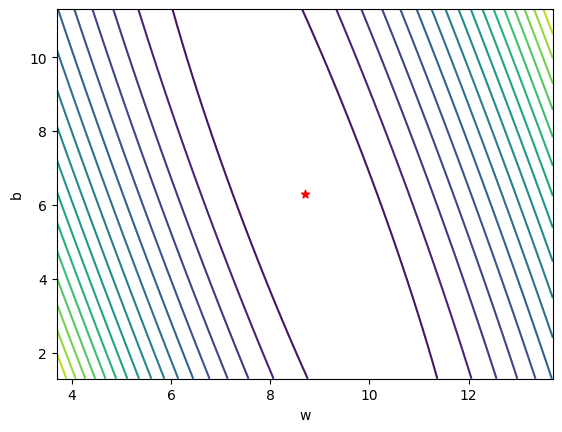

In [ ]:
# 3 qadam: cost function sirtini vizual chizamiz

cost = sp.lambdify((w, b), C, "numpy")
sol = sp.solve([dC_dw, dC_db], [w, b])
w_opt, b_opt = float(sol[w]), float(sol[b])
W, B = np.meshgrid(
    np.linspace(w_opt - 5, w_opt + 5, 100),
    np.linspace(b_opt - 5, b_opt + 5, 100)
)
plt.contour(W, B, cost(W, B), 20)
plt.scatter([w_opt], [b_opt], c='red', marker="*")
plt.xlabel('w')
plt.ylabel('b')
plt.show()

In [ ]:
# 4-qadam: gradient descentni ishga tushiramiz
x = np.array([1, 2, 3, 4, 5]);
y = np.array([15, 25, 30, 42, 50])
w, b = 0.0, 0.0
lr = 0.02
for step in range(200):
  pred = w * x + b
  dCdw = np.mean(2 * x * (pred - y))
  dCdb = np.mean(2 * (pred - y))
  w -= lr * dCdw
  b -= lr * dCdb
print(f"w={w:.3f}, b={b:.3f}, cost={cost(w, b):.3f}")
# natija: w = 8.958, b=5.370, cost =  1.817

w=8.958, b=5.370, cost=1.817


In [ ]:
# natijani symbolic tekshiramiz
w, b = sp.symbols('w b')
C = sum((w*xv + b - yv)**2
        for xv, yv in zip(x_data, y_data)) / len(x_data)
yechim = sp.solve([sp.diff(C, w), sp.diff(C, b)], [w, b])
print(yechim)  # {w: 87/10, b: 63/10}
# sp.solve  C funksiyani w, b boyicha hosilalarini olib nolga tenglab w va b ni topish

{b: 63/10, w: 87/10}


In [ ]:
w, b = sp.symbols('w b')
x = np.array([2, 6, 4, 8, 9])
y = np.array([7, 17, 20, 19, 22])
C = sum((w*xv + b - yv)**2 for xv, yv in zip(x, y)) / len(x)
print(sp.expand(C))

b**2 + 58*b*w/5 - 34*b + 201*w**2/5 - 1092*w/5 + 1583/5


In [ ]:
dC_dw = sp.diff(C, w)
dC_db = sp.diff(C, b)
print(dC_dw)
print(dC_db)

print(float(dC_dw.subs({w: 0, b: 0})), float(dC_db.subs({w: 0, b: 0})))

58*b/5 + 402*w/5 - 1092/5
2*b + 58*w/5 - 34
-218.4 -34.0


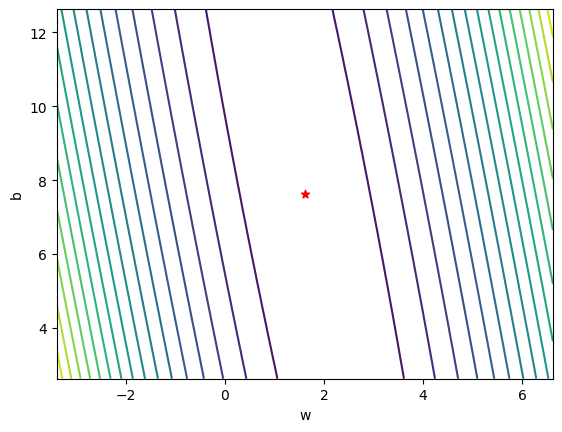

In [ ]:
cost = sp.lambdify((w, b), C, "numpy")
sol = sp.solve([dC_dw, dC_db], [w, b])
w_opt, b_opt = float(sol[w]), float(sol[b])
W, B = np.meshgrid(
    np.linspace(w_opt - 5, w_opt + 5, 100),
    np.linspace(b_opt - 5, b_opt + 5, 100)
)
plt.contour(W, B, cost(W, B), 20)
plt.scatter([w_opt], [b_opt], c='red', marker="*")
plt.xlabel('w')
plt.ylabel('b')
plt.show()

In [ ]:
w, b = 0.0, 0.0
lr = 0.02
for step in range(2000):
  pred = w * x + b
  dCdw = np.mean(2 * x * (pred - y))
  dCdb = np.mean(2 * (pred - y))
  w -= lr * dCdw
  b -= lr * dCdb
print(f"w={w:.3f}, b={b:.3f}, cost={cost(w, b):.3f}")

w=1.616, b=7.628, cost=10.472


In [ ]:
# ================================================================== #

In [ ]:
# 1-qadam: sigmoid funksiyasi va uning hosilasi
z = sp.symbols('z')
sigmoid = 1/(1+sp.exp(-z))
d_sigmoid = sp.diff(sigmoid, z)
print(sp.simplify(d_sigmoid))  # 1/(4*cosh(z/2)**2)
print(sp.simplify(d_sigmoid - sigmoid * (1 - sigmoid)))  # 0

1/(4*cosh(z/2)**2)
0


In [ ]:
# 2-qadam: chain role bilan gradientni chiqaramiz
w, x, y, b = sp.symbols('w x y b')
p = 1 / (1 + sp.exp(-(w*x + b)))
Loss = -(y*sp.log(p) + (1-y)*sp.log(1-p)) # binary cross-entropy
dLoss_dw = sp.diff(Loss, w)
print(sp.simplify(dLoss_dw - (p - y)*x)) # 0  -> dLoss/dw = (p-y)*x

0


In [ ]:
# 3-qadam: logistik regressiyani o'qitamiz
def sigmoid(z): return 1 / (1 + np.exp(-z))
x = np.array([1, 2, 3, 4, 5, 6, 7, 8])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1])
w, b, lr = 0.0, 0.0, 0.1
for step in range(2000):
  pred = sigmoid(w * x + b)
  dw = np.mean((pred - y) * x)  # chain role natijasi!
  db = np.mean(pred - y)
  w -= lr * dw
  b -= lr * db
print(f"w={w:.3f}, b={b:.3f}")  # w=1.165, b=-5.198
print(np.round(sigmoid(w*x + b), 3)) # [0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]

w=1.165, b=-5.198
[0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]


In [ ]:
# ROC nuqtalarini modelning o'z ehtimolliklaridan hisoblaymiz
p = sigmoid(w*x+b)
tpr, fpr = [0.0], [0.0]

for t in np.sort(np.unique(p))[::-1]:  # chegaralar: kattadan kichikka
  pred = (p >= t).astype(int)
  tpr.append(np.sum((pred == 1) & (y == 1)) / np.sum( y == 1))
  fpr.append(np.sum((pred == 1) & (y == 0)) / np.sum(y == 0))


auc = np.trapezoid(tpr, fpr)
print(f"AUC -> {auc}")  # AUC -> 0.9375
# auc rate 0.5 da xato ishlaydi. undan katta bo'lishi kerak lekin u 0.5 ga teng bo'lmasligi kerak.

AUC -> 0.9375



==================== 1-to'plam ====================
Xatolik funksiyasi (C): b**2 + 6.0*b*w - 64.8*b + 11.0*w**2 - 229.2*w + 1202.8
dC/dw: 6.0*b + 22.0*w - 229.2
dC/db: 2*b + 6.0*w - 64.8
Gradient (w=0, b=0): dC/dw = -229.20, dC/db = -64.80
Analitik optimal parametrlar: w = 8.7000, b = 6.3000


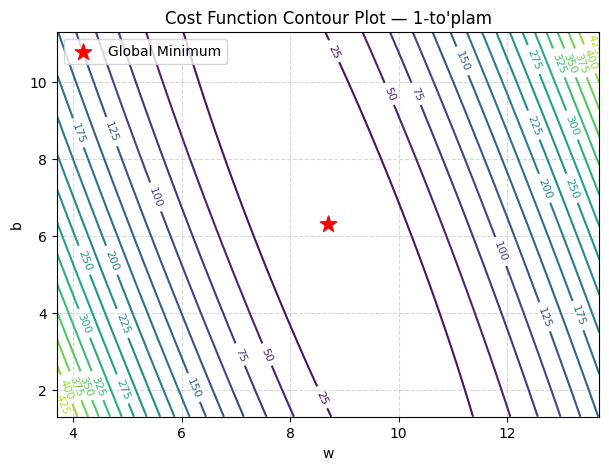

Gradient Descent natijasi (300 qadam):
w = 8.831, b = 5.828, yakuniy xatolik = 1.701

==================== 2-to'plam ====================
Xatolik funksiyasi (C): b**2 + 11.6*b*w - 34.0*b + 40.2*w**2 - 218.4*w + 316.6
dC/dw: 11.6*b + 80.4*w - 218.4
dC/db: 2*b + 11.6*w - 34.0
Gradient (w=0, b=0): dC/dw = -218.40, dC/db = -34.00
Analitik optimal parametrlar: w = 1.6159, b = 7.6280


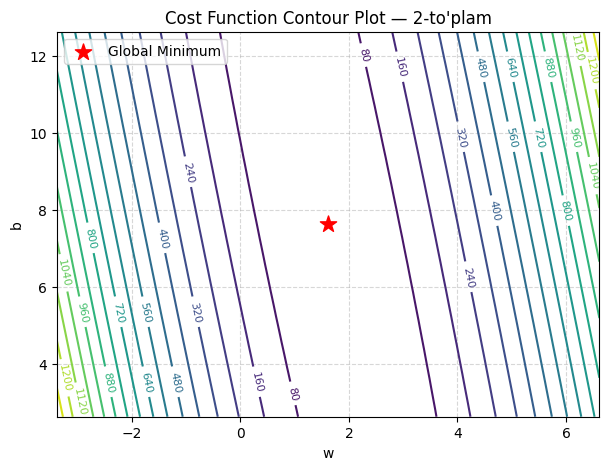

Gradient Descent natijasi (2000 qadam):
w = 1.616, b = 7.628, yakuniy xatolik = 10.472


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

def run_linear_regression(x_data, y_data, lr=0.02, steps=1000, name="Dataset"):
    print(f"\n{'='*20} {name} {'='*20}")

    # 1. Simvolik (analitik) hosilalar va optimal nuqta
    w, b = sp.symbols('w b')
    n = len(x_data)

    # O'rtacha kvadratik xatolik (MSE Cost funksiyasi)
    C = sum((w * xv + b - yv)**2 for xv, yv in zip(x_data, y_data)) / n
    print("Xatolik funksiyasi (C):", sp.expand(C))

    dC_dw = sp.diff(C, w)
    dC_db = sp.diff(C, b)
    print("dC/dw:", dC_dw)
    print("dC/db:", dC_db)

    # w=0, b=0 nuqtasidagi boshlang'ich gradient
    init_grad_w = float(dC_dw.subs({w: 0, b: 0}))
    init_grad_b = float(dC_db.subs({w: 0, b: 0}))
    print(f"Gradient (w=0, b=0): dC/dw = {init_grad_w:.2f}, dC/db = {init_grad_b:.2f}")

    # Analitik yechim (hosilalarni 0 ga tenglab yechish)
    sol = sp.solve([dC_dw, dC_db], [w, b])
    w_opt, b_opt = float(sol[w]), float(sol[b])
    print(f"Analitik optimal parametrlar: w = {w_opt:.4f}, b = {b_opt:.4f}")

    # 2. Xatolik sirti (Contour Plot)
    cost_func = sp.lambdify((w, b), C, "numpy")
    W, B = np.meshgrid(
        np.linspace(w_opt - 5, w_opt + 5, 100),
        np.linspace(b_opt - 5, b_opt + 5, 100)
    )

    plt.figure(figsize=(7, 5))
    contours = plt.contour(W, B, cost_func(W, B), levels=20, cmap='viridis')
    plt.clabel(contours, inline=True, fontsize=8)
    plt.scatter([w_opt], [b_opt], color='red', marker="*", s=150, label='Global Minimum')
    plt.title(f'Cost Function Contour Plot — {name}')
    plt.xlabel('w')
    plt.ylabel('b')
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # 3. Sonli usul: Gradient Descent
    w_gd, b_gd = 0.0, 0.0
    for _ in range(steps):
        pred = w_gd * x_data + b_gd
        err = pred - y_data
        dCdw = np.mean(2 * x_data * err)
        dCdb = np.mean(2 * err)

        w_gd -= lr * dCdw
        b_gd -= lr * dCdb

    print(f"Gradient Descent natijasi ({steps} qadam):")
    print(f"w = {w_gd:.3f}, b = {b_gd:.3f}, yakuniy xatolik = {cost_func(w_gd, b_gd):.3f}")


# 1-to'plam ustida sinov
x1 = np.array([1, 2, 3, 4, 5], dtype=float)
y1 = np.array([15, 25, 30, 42, 50], dtype=float)
run_linear_regression(x1, y1, lr=0.02, steps=300, name="1-to'plam")

# 2-to'plam ustida sinov
x2 = np.array([2, 6, 4, 8, 9], dtype=float)
y2 = np.array([7, 17, 20, 19, 22], dtype=float)
run_linear_regression(x2, y2, lr=0.02, steps=2000, name="2-to'plam")


==================== Logistik Regressiya va ROC-AUC ====================
✓ Sigmoid hosilasi isbotlandi: d(sigmoid)/dz = sigmoid * (1 - sigmoid)
✓ BCE gradienti isbotlandi: dLoss/dw = (p - y) * x

O'qitilgan parametrlar: w = 1.165, b = -5.198
Bashorat qilingan ehtimolliklar: [0.017 0.054 0.154 0.369 0.652 0.857 0.951 0.984]
Modelning AUC ko'rsatkichi: 0.9375


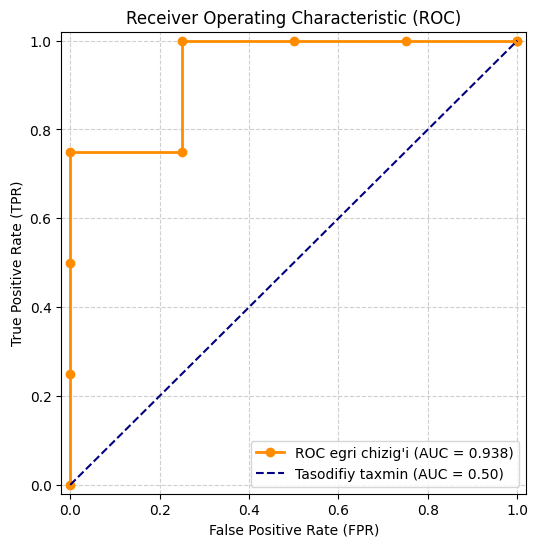

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

print(f"\n{'='*20} Logistik Regressiya va ROC-AUC {'='*20}")

# 1. Matematik isbotlar (SymPy)
z = sp.symbols('z')
sig = 1 / (1 + sp.exp(-z))
d_sig = sp.diff(sig, z)
assert sp.simplify(d_sig - sig * (1 - sig)) == 0
print("✓ Sigmoid hosilasi isbotlandi: d(sigmoid)/dz = sigmoid * (1 - sigmoid)")

w, x, y, b = sp.symbols('w x y b')
p = 1 / (1 + sp.exp(-(w * x + b)))
loss = -(y * sp.log(p) + (1 - y) * sp.log(1 - p))
dloss_dw = sp.diff(loss, w)
assert sp.simplify(dloss_dw - (p - y) * x) == 0
print("✓ BCE gradienti isbotlandi: dLoss/dw = (p - y) * x")


# 2. Gradient Descent orqali modelni o'qitish
def sigmoid(val):
    return 1 / (1 + np.exp(-val))

x_train = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y_train = np.array([0, 0, 0, 1, 0, 1, 1, 1], dtype=float)

w_log, b_log = 0.0, 0.0
learning_rate = 0.1
epochs = 2000

for _ in range(epochs):
    preds = sigmoid(w_log * x_train + b_log)
    err = preds - y_train
    dw = np.mean(err * x_train)
    db = np.mean(err)

    w_log -= learning_rate * dw
    b_log -= learning_rate * db

probabilities = sigmoid(w_log * x_train + b_log)
print(f"\nO'qitilgan parametrlar: w = {w_log:.3f}, b = {b_log:.3f}")
print("Bashorat qilingan ehtimolliklar:", np.round(probabilities, 3))
# 3. ROC egri chizig'ini qurish va AUC hisoblash
# Nuqtalar boshlanishi: (0, 0)
fpr = [0.0]
tpr = [0.0]

thresholds = np.sort(np.unique(probabilities))[::-1]

for t in thresholds:
    binary_preds = (probabilities >= t).astype(int)

    tp = np.sum((binary_preds == 1) & (y_train == 1))
    fp = np.sum((binary_preds == 1) & (y_train == 0))

    tpr.append(tp / np.sum(y_train == 1))
    fpr.append(fp / np.sum(y_train == 0))

# Nuqtalar oxiri: (1, 1)
fpr.append(1.0)
tpr.append(1.0)

# Trapetsiya qoidasi bo'yicha AUC (x=FPR, y=TPR)
auc_score = np.trapezoid(tpr, fpr)
print(f"Modelning AUC ko'rsatkichi: {auc_score:.4f}")

# 4. ROC grafigini chizish
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker='o', color='darkorange', lw=2, label=f'ROC egri chizig\'i (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Tasodifiy taxmin (AUC = 0.50)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.show()